# EDA v4 — Datathon 2026 *The Gridbreakers* (reproducibility notebook)

This notebook is a thin wrapper around the canonical script `eda_v4.py`. Running all cells regenerates every number in `metrics_v4.json` and every figure in `images/` from the raw CSVs in `../../data/`.

**Design choice.** All analytical logic lives in one audit-friendly script; the notebook is only for inline inspection and HTML/PDF export so the grader can reproduce the pipeline in one click.

Run:

```bash
uv run jupyter nbconvert --to html --execute results/v4/eda_v4.ipynb
```

## 1. Execute the canonical pipeline

Loads 14 CSVs, builds the daily panel, runs statistical tests (Welch t-test, Mann-Whitney U, Spearman panel, inventory correlations), writes `metrics_v4.json`, and renders 5 multi-panel figures as vector PDF + PNG.

In [1]:
%run eda_v4.py

[1/6] Loading tables ...


[2/6] Building daily panel ...


[3/6] Running statistical tests ...


  -> metrics_v4.json (53 keys)
[4/6] Rendering figures ...


[5/6] Saving metrics ...


[6/6] Done. Outputs:
  - results/v4/Makefile
  - results/v4/eda_v4.ipynb
  - results/v4/eda_v4.py
  - results/v4/images/fig1_system_overview.pdf
  - results/v4/images/fig1_system_overview.png
  - results/v4/images/fig2_seasonality.pdf
  - results/v4/images/fig2_seasonality.png
  - results/v4/images/fig3_structural.pdf
  - results/v4/images/fig3_structural.png
  - results/v4/images/fig4_operations.pdf
  - results/v4/images/fig4_operations.png
  - results/v4/images/fig5_forecast_readiness.pdf
  - results/v4/images/fig5_forecast_readiness.png
  - results/v4/metrics_v4.json
  - results/v4/report.pdf
  - results/v4/report.tex
  - results/v4/summary.md


## 2. Inspect the key numbers

In [2]:
import json, pandas as pd
from pathlib import Path
m = json.loads(Path('metrics_v4.json').read_text())
print('Train days        :', m['train_days'])
print('Regime drop %     :', round(m['regime.drop_pct'], 2))
print('Regime t / p      :', round(m['regime.t_stat'], 2), '/', f"{m['regime.p_value']:.2e}")
print('Cohen d           :', round(m['regime.cohen_d'], 2))
print('Top month (+%)    :', m['seasonality.top_month'], '+', round(m['seasonality.top_month_pct'],1), '%')
print('Bottom month (%)  :', m['seasonality.bottom_month'], round(m['seasonality.bottom_month_pct'],1), '%')
print('Category HHI      :', round(m['category.hhi'], 3))
print('Streetwear share %:', round(m['category.top_share_pct'], 1))
print('Promo gap median %:', round(m['promo.gap_median_pct'], 2), ' (U p=', f"{m['promo.p_value']:.2e}", ')')
print('Top 20% cust share%:', round(m['customers.top20_pct'], 1))
print('Repeat rate %     :', round(m['customers.repeat_pct'], 1))

Train days        : 3833
Regime drop %     : 40.55
Regime t / p      : 28.57 / 7.60e-163
Cohen d           : 0.89
Top month (+%)    : 5 + 53.4 %
Bottom month (%)  : 12 -41.1 %
Category HHI      : 0.665
Streetwear share %: 80.1
Promo gap median %: 13.33  (U p= 1.40e-12 )
Top 20% cust share%: 60.7
Repeat rate %     : 75.2


## 3. Display all figures inline

### fig1_system_overview

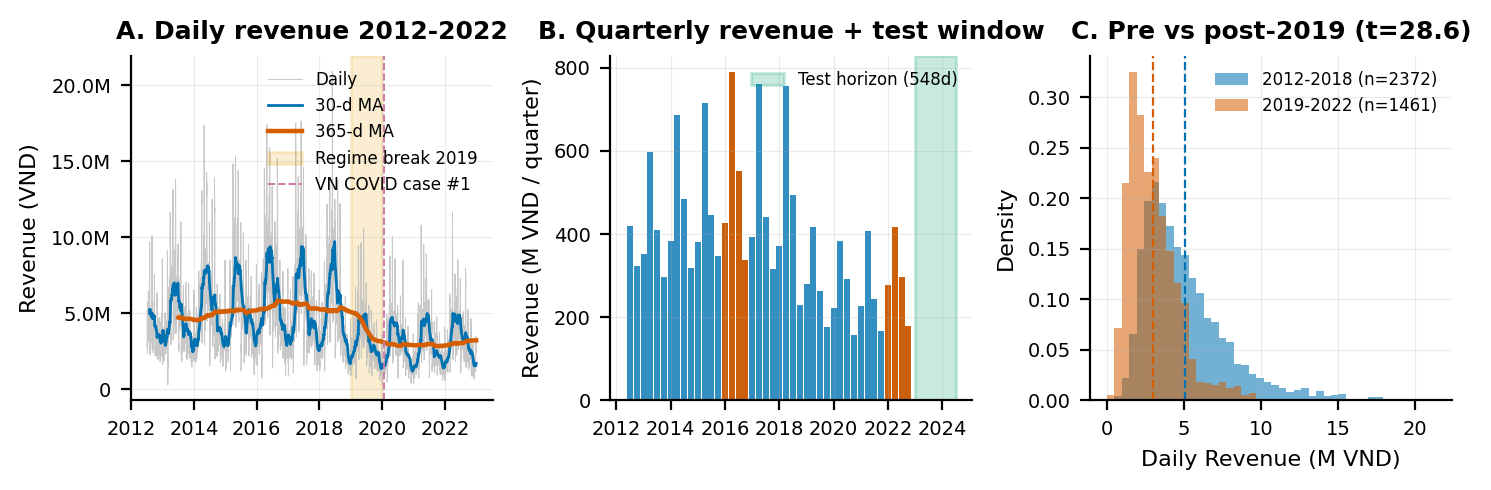

### fig2_seasonality

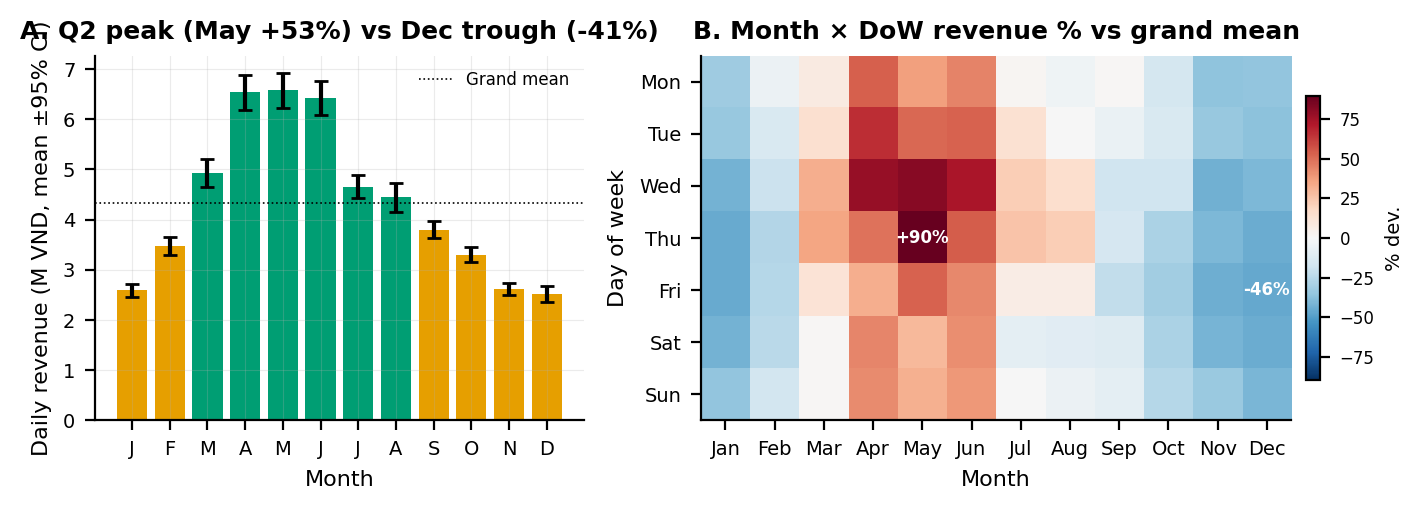

### fig3_structural

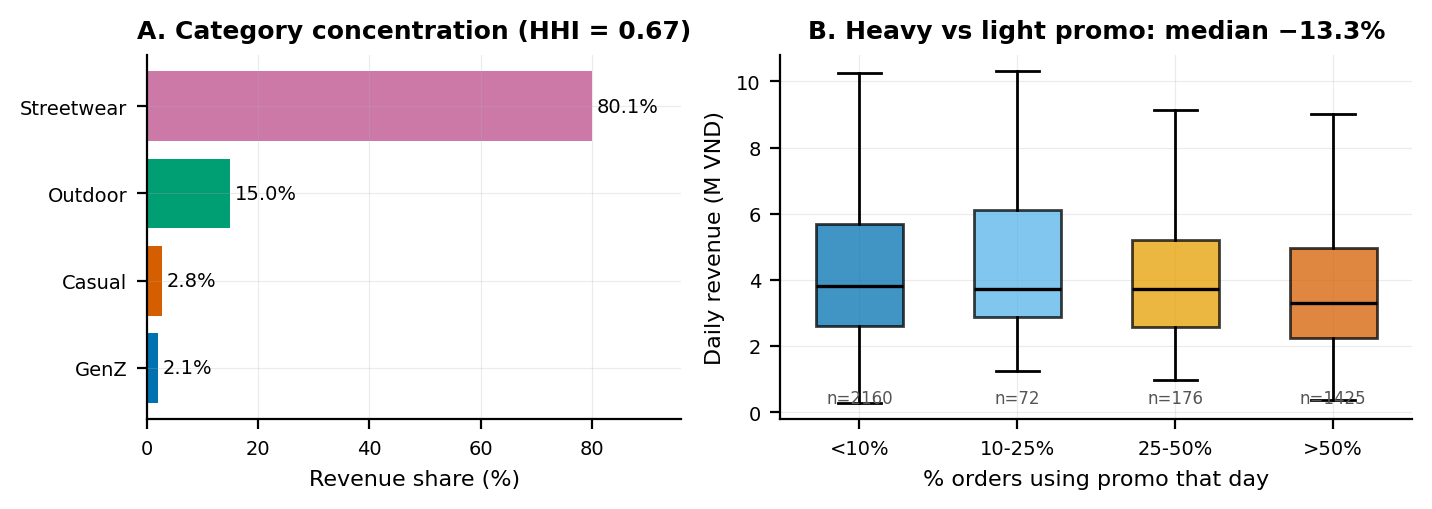

### fig4_operations

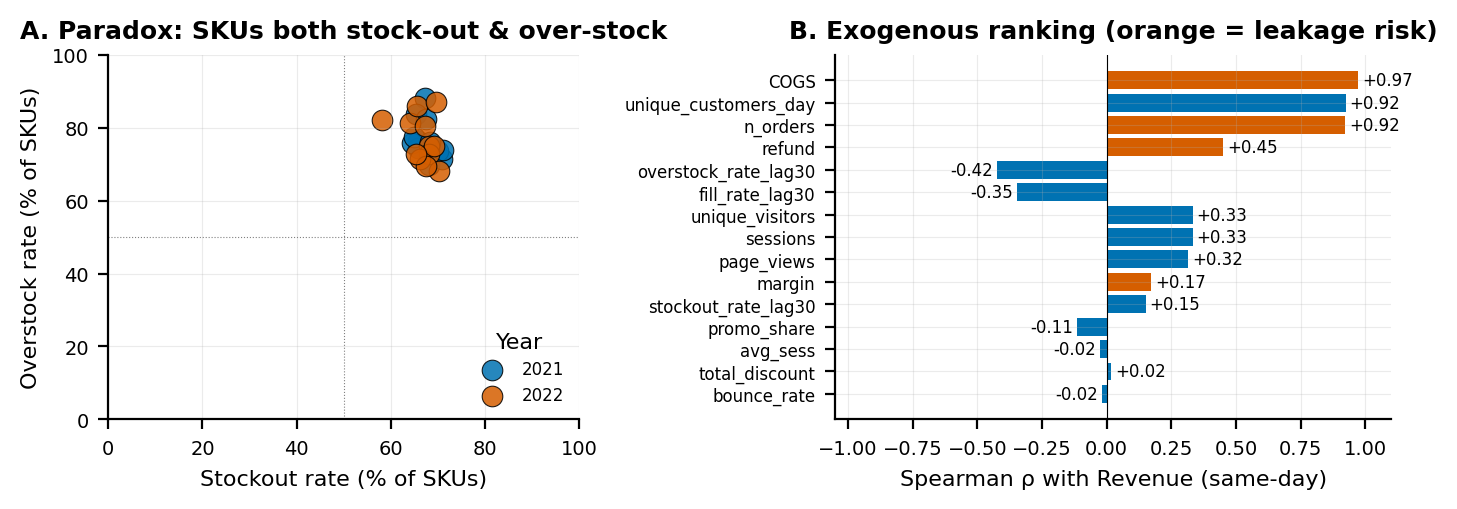

### fig5_forecast_readiness

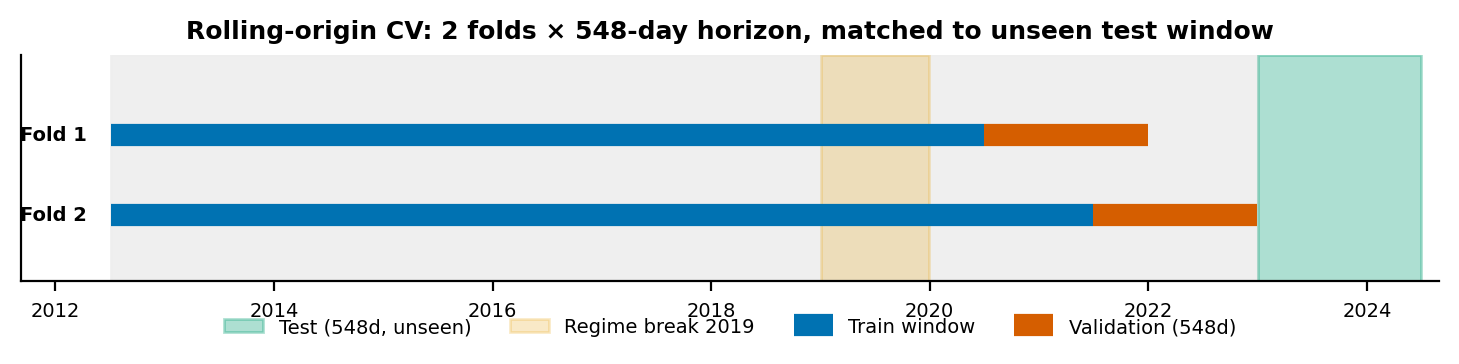

In [3]:
from IPython.display import Image, display, Markdown
for name in ['fig1_system_overview', 'fig2_seasonality', 'fig3_structural', 'fig4_operations', 'fig5_forecast_readiness']:
    display(Markdown(f"### {name}"))
    display(Image(filename=f'images/{name}.png'))

## 4. Exogenous feature ranking (leakage-tagged)

Orange features have same-day leakage risk and are blacklisted from Part 3 modelling without an explicit lag.

In [4]:
leakage = {'COGS', 'n_orders', 'refund', 'margin', 'unique_customers_day'}
ranks = pd.Series(m['exogenous.spearman']).sort_values(key=lambda s: s.abs(), ascending=False)
out = pd.DataFrame({'feature': ranks.index, 'spearman_rho': ranks.round(3).values,
                    'leakage_risk': [f in leakage for f in ranks.index]})
out

,feature,spearman_rho,leakage_risk
0,COGS,0.972,True
1,unique_customers_day,0.924,True
2,n_orders,0.923,True
3,refund,0.451,True
4,overstock_rate_lag30,-0.424,False
5,fill_rate_lag30,-0.346,False
6,unique_visitors,0.333,False
7,sessions,0.332,False
8,page_views,0.316,False
9,margin,0.171,True


## 5. Reproducibility footer

- Script SHA-256 of `eda_v4.py` (displayed below) uniquely identifies the pipeline version.
- All numbers referenced in `report.pdf` are available in `metrics_v4.json` (no hand-typed values).

In [5]:
import hashlib
print('eda_v4.py SHA-256:', hashlib.sha256(Path('eda_v4.py').read_bytes()).hexdigest())

eda_v4.py SHA-256: 068a08509e191ec17c6a7f1d58f746e86193a22dc9c5636a427bace1a2c5a434
